<div class="alert alert-info"> 
    
# IX. Exercise: Putting it All Together

This exercise is in a separate file from the main lesson so that you can more easily reference the content in the Numpy and Pandas lessons if you need to by having multiple files open side-by-side in Jupyter Lab.

In this exercise you will use NumPy (as well as Pandas and matplotlib) to read multiple csv files, create numpy arrays, execute calculations, and visualize results. The data files contain the Nino3.4 Index as well as monthly precipitation anomalies at 10 different US cities. Your task will be to get this data into NumPy arrays, calculate the mean precipitation anomaly at each city during El Nina and La Nina months, and visualize your calculations.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-info"> 

## 1) Intro to the El Nino Southern Oscillation (ENSO)
Start by watching this short video about the El Nino Southern Oscillation climate phenomenon and how it affects precipitation and temperature in the United States.

<video controls width="560" src="https://oceanservice.noaa.gov/facts/elninolanina/otkn_721_elninolanina_lg.mp4"></video>

As you saw in the video, ENSO is a feature of Earth's natural climate variability that impacts weather globally. It has 3 phases: El Nino (warm tropical Pacific), La Nina (cool tropical Pacific), and neutral (normal tropical Pacific). Over North America, the phase of ENSO modulates the location of the jet stream and the storm systems that travel along it. This results in areas of wetter/drier and cooler/warmer weather during El Nino and La Nina conditions. Weather impacts from El Nino and La Nina are generally strongest in winter months over North America. The strongest ENSO influence on US precipitation is seen in the southern United States from southern California to Florida. 

Scientists have developed a few different *indexes* for tracking the phase and strength of ENSO over time. The ENSO index we will use in this exercise is called the Nino3.4 Index. This index is created from monthly sea surface temperature anomalies (departure from the long term mean) from a region in the tropical Pacific ocean known as the Nino3.4 region. 

For the purposes of this exercise, we will select months with El Nino and La Nina using the following criteria:
- El Nino conditions - months when the Index is greater than or equal to +1
- La Nina conditions - months when the Index is less than or equal to -1
  
The way research scientists identify El Nino and La Nina events from the Nino3.4 Index is little bit more complex. We won't get into the details here though since this exercise is focused on NumPy practice, not scientific rigor.
</div>

<div class="alert alert-info"> 

## 2) Read ENSO Data into NumPy Array, Prepare Data for Analysis, and Visualize
Use a NumPy function to read the file at ```data/NOAA_ClimateIndex/Nino34ClimateIndex.txt``` into a NumPy array called ```enso``` with 32-bit floating point data values. Render a preview of the array to the screen.
</div>

In [52]:
# add your code here

enso = np.loadtxt('data/NOAA_ClimateIndex/Nino34ClimateIndex.txt',
                     skiprows=1,
                     max_rows=78,
                     dtype='float32')
enso

array([[ 1.948e+03, -9.999e+01, -9.999e+01, ..., -9.999e+01, -9.999e+01,
        -9.999e+01],
       [ 1.949e+03, -9.999e+01, -9.999e+01, ..., -9.999e+01, -9.999e+01,
        -9.999e+01],
       [ 1.950e+03, -1.990e+00, -1.690e+00, ..., -1.030e+00, -1.230e+00,
        -1.310e+00],
       ...,
       [ 2.023e+03, -7.200e-01, -4.600e-01, ...,  1.720e+00,  2.020e+00,
         2.030e+00],
       [ 2.024e+03,  1.810e+00,  1.520e+00, ..., -2.700e-01, -2.500e-01,
        -6.000e-01],
       [ 2.025e+03, -7.500e-01, -5.900e-01, ..., -9.999e+01, -9.999e+01,
        -9.999e+01]], shape=(78, 13), dtype=float32)

In [53]:
# alternatively...
# enso = np.genfromtxt('data/NOAA_ClimateIndex/Nino34ClimateIndex.txt',
#                      skip_header=1,
#                      skip_footer=3,
#                      dtype='float32')
# enso

<div class="alert alert-info"> 
    
Missing data values are represented with -99.99 in this data. The first and second rows (1948 and 1949) as well as the last row (2025) contain missing data. Use indexing to eliminate those rows, overwriting the ```enso``` array. From your new ```enso``` array, print the shape, first, and last row of data values.
</div>

In [54]:
# add your code here
enso = enso[2:-1,:]
print(enso.shape)
print(enso[0,:])
print(enso[-1,:])

(75, 13)
[ 1.95e+03 -1.99e+00 -1.69e+00 -1.42e+00 -1.54e+00 -1.75e+00 -1.27e+00
 -1.01e+00 -9.70e-01 -9.80e-01 -1.03e+00 -1.23e+00 -1.31e+00]
[ 2.024e+03  1.810e+00  1.520e+00  1.130e+00  7.700e-01  2.300e-01
  1.700e-01  4.000e-02 -1.200e-01 -2.600e-01 -2.700e-01 -2.500e-01
 -6.000e-01]


<div class="alert alert-info"> 

Get the years from the ```enso``` array and save them into their own variable called ```year``` with 16-bit integer data type. Print the ```year``` array to the screen.
</div>

In [55]:
# add your code here
year = enso[:,0].astype('int16')
year

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype=int16)

<div class="alert alert-info"> 

Overwrite the ```enso``` array to not include the years, such that you retain only the monthly nino3.4 data values. Print the first 5 values of the first column of ```enso``` to the screen to double check that the years have been removed correctly.
</div>

In [56]:
# add your code here
enso = enso[:,1:]
enso[:5,0]

array([-1.99, -1.3 ,  0.13,  0.2 ,  0.43], dtype=float32)

<div class="alert alert-info"> 

Verify programmatically that there are no missing values (-99.99) remaining in the ```enso``` array.
</div>

In [57]:
print((enso==-99.99).sum())

0


<div class="alert alert-info"> 

Create a Pandas DatetimeIndex called ```time``` of monthly datetimes for all the years in ```year```. The day in each datetime should be the first day of the month. 


In [58]:
time = pd.date_range('1950-01','2024-12',freq='MS')
time

DatetimeIndex(['1950-01-01', '1950-02-01', '1950-03-01', '1950-04-01',
               '1950-05-01', '1950-06-01', '1950-07-01', '1950-08-01',
               '1950-09-01', '1950-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', length=900, freq='MS')

<div class="alert alert-info"> 

Convert ```enso``` from a 2D to a 1D NumPy array and save the result to a new variable called ```enso1D```. ```enso1D``` should contain the values of the Nino3.4 Index sequentially in time from 1950 to 2024. 

</div>

In [59]:
# add your code here
enso1D = enso.flatten()
enso1D.shape

(900,)

<div class="alert alert-info"> 

Check your work by:
- using an ```np.testing``` assert function to test if the first 12 values of the ```enso1D``` array are equal to the first row of ```enso``` array, use a tolerance of two decimal places
- use Python ```assert()``` to test if the length of the ```enso1D``` array is equal to the length of the ```time``` DatetimeIndex


In [65]:
# add your code here
np.testing.assert_allclose(enso1D[0:12],enso[0,:],rtol=1E-3)
assert len(enso1D)==len(time),'length of enso_arr and time do not match'

<div class="alert alert-info"> 

Plot the Nino3.4 Index timeseries (```enso1D```) with matplotlib.pyplot (```plt```). Include the following:
- use the DateTimeIndex ```time``` for the x values
- stretch your figure width using the parameter ```figsize=(10,2)```
- include a grey dashed reference line at y=0
- include a title

</div>

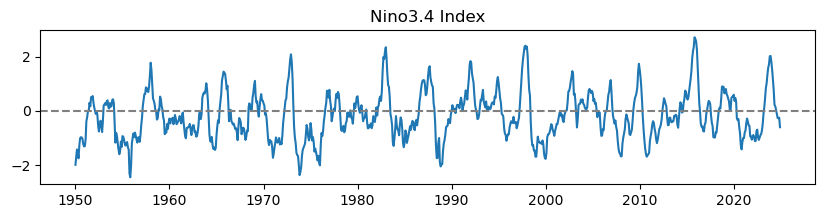

In [10]:
# add your code here
fig = plt.figure(figsize=(10,2))
plt.plot(time,enso1D)
plt.axhline(0,color='grey',ls='dashed')
plt.title('Nino3.4 Index')
plt.show()

<div class="alert alert-info"> 

## 3) Read the Precipitation Data Files

The monthly precipitation anomalies are provided in two separate files for your *in*convenience so you can practice combining data from multiple files. The two files are: 

- ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_8cities.csv```
- ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_2cities.csv```

Each row of data in these files contains the following information: the city name, latitude, longitude, precipitation units, base period used to create the anomalies, link to the original data source, data access date, and monthly precipitation anomaly values.  

There are multiple ways to get the precipitation anomalies from these two files into a single NumPy array. The next steps will guide you through one method that allows you to practice using both Pandas and NumPy functions.

Read the file at ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_8cities.csv``` into a Pandas dataframe called ```df1``` and render the head to the screen.
</div>

In [11]:
# add your code here
df1 = pd.read_csv('data/nclimgrid/pr_anomaly_nclimgrid_monthly_8cities.csv')
df1.head()

,CITY,LATITUDE,LONGITUDE,UNITS,BASE,SOURCE,ACCESSED,1950-01-01 00:00:00,1950-02-01 00:00:00,1950-03-01 00:00:00,...,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00
0,San Diego,32.812534,-117.145836,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,24.260742,-29.877510,-15.437077,...,33.333430,-11.200521,-3.815039,-1.198763,-0.830371,0.568099,-3.070801,-13.003613,-18.404720,-44.571907
1,Tucson,32.187534,-110.895836,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-19.914062,8.528027,-12.281836,...,15.957422,11.647949,-4.493327,15.638867,9.600422,-15.562370,-24.553972,-16.139616,-2.849024,-29.774350
2,El Paso,31.770866,-106.479164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-2.001856,-4.027083,-5.530696,...,-4.580501,-3.317741,-7.582292,-4.118620,-10.607456,-26.614616,-28.582650,-15.280859,10.365202,-14.309668
3,Austin,30.270866,-97.729164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-44.206543,42.778973,-48.979850,...,-23.460320,14.113670,11.750687,-33.024544,54.006542,-29.506771,-77.203810,-105.855630,-20.089775,-29.711357
4,Houston,29.770866,-95.354164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,2.015236,63.515656,-67.185450,...,-3.505760,-1.802376,103.618484,-19.365753,249.633670,-87.673280,-85.412110,-103.408690,-17.276726,-20.919952


<div class="alert alert-info"> 

What is the year and month of the first column of precipitation anomalies in this file? Does this match the starting year and month of your ```enso_arr``` data? 
</div>

Type your answer: 1950-01, yes

<div class="alert alert-info"> 

Create a 2D NumPy array called ```pr``` of the precipitation anomalies in ```df1``` where the first dimension represents the location and the second dimension represents the dates. Verify that the shape of your array is (8,900).
</div>

In [12]:
# add your code here
pr = df1.loc[:,'1950-01-01 00:00:00':].to_numpy()
pr.shape

(8, 900)

<div class="alert alert-info"> 

Read the file at ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_2cities.csv``` into a Pandas dataframe called ```df2``` and render the head to the screen.
</div>

In [13]:
# add your code here
df2 = pd.read_csv('data/nclimgrid/pr_anomaly_nclimgrid_monthly_2cities.csv')
df2.head()

,CITY,LATITUDE,LONGITUDE,UNITS,BASE,SOURCE,ACCESSED,1949-01-01 00:00:00,1949-02-01 00:00:00,1949-03-01 00:00:00,...,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00
0,Jacksonville,30.312532,-81.645836,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-54.618004,58.635582,-62.41195,...,61.688637,-27.230309,-10.912697,-94.11972,53.336746,111.819824,138.871610,-32.89235,-30.605210,-32.650032
1,Orlando,28.479200,-81.354164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-58.896027,-37.726433,-59.68490,...,-38.394860,-30.413345,-37.702835,-36.02507,-38.789460,30.451310,20.322983,87.21250,-21.253971,-24.752995


<div class="alert alert-info"> 

What is the year and month of the first column of precipitation anomalies in this file? Does this match the starting year and month of your ```enso_arr``` data? 
</div>

Type your answer: 1949-01, no

<div class="alert alert-info"> 

Create a 2D NumPy array called ```more_pr``` of the precipitation anomalies in ```df2``` where the first dimension represents the location and the second dimension represents the dates. Verify that the shape of your array is (2,900).
</div>

In [14]:
# add your code here
more_pr = df2.loc[:,'1950-01-01 00:00:00':].to_numpy()
more_pr.shape

(2, 900)

<div class="alert alert-info"> 

Concatenate the ```pr``` and ```more_pr``` arrays together. Continue using the variable name ```pr``` for the final combined data. Verify that your new ```pr``` array has the shape (10,900)
</div>

In [15]:
# add your code here
pr = np.concatenate([pr,more_pr])
pr.shape

(10, 900)

<div class="alert alert-info"> 
    
Count how many NaNs there are in the ```pr``` array. 
</div>

In [16]:
# add your code here
print(np.isnan(pr).sum())

0


<div class="alert alert-info"> 
    
Convert ```pr``` from units of mm to units of inches.
</div>

In [17]:
# add your code here
pr = pr / 25.4

<div class="alert alert-info"> 
    
Create a 1D NumPy array of city names called ```city_names``` to match the order of the 10 cities in your ```pr``` array. This can be accomplished with Pandas or NumPy functions, the choice is yours.
</div>

In [24]:
# add your code here
# using a numpy function
city_names = np.concatenate([df1['CITY'],df2['CITY']])
print(type(city_names))
city_names

<class 'numpy.ndarray'>


array(['San Diego', 'Tucson', 'El Paso', 'Austin', 'Houston',
       'New Orleans', 'Mobile', 'Augusta', 'Jacksonville', 'Orlando'],
      dtype=object)

In [25]:
# alternatively...
# using pandas functions
city_names = pd.concat([df1['CITY'],df2['CITY']],axis=0,ignore_index=True).to_numpy()
print(type(city_names))
city_names

<class 'numpy.ndarray'>


array(['San Diego', 'Tucson', 'El Paso', 'Austin', 'Houston',
       'New Orleans', 'Mobile', 'Augusta', 'Jacksonville', 'Orlando'],
      dtype=object)

In [41]:
city_names=np.array(list(df1['CITY'])+list(df2['CITY']))
# city_names=list(df1['CITY'])+list(df2['CITY'])
print(type(city_names))
city_names


<class 'numpy.ndarray'>


array(['San Diego', 'Tucson', 'El Paso', 'Austin', 'Houston',
       'New Orleans', 'Mobile', 'Augusta', 'Jacksonville', 'Orlando'],
      dtype='<U12')

<div class="alert alert-info"> 

## 4) Use Advanced Indexing to Find Mean Precipitation Anomalies during El Nino and La Nina Months

Find the array indexes in ```enso_arr``` where the Nino3.4 Index is:
- greater than or equal to +1.0, save to a variable called ```nino_inds```
- less than or equal to -1.0, save to a variable called ```nina_inds```

Make sure your ```nino_inds``` and ```nina_inds``` variables are array objects, not tuple objects with an array inside.

In [33]:
nino_inds = (enso1D>=1)
nina_inds = (enso1D<=-1)
# nino_inds

In [ ]:
# # by the way, if you wanted to get the index positions of where the condition is True...
# test=np.asarray(enso_arr>=1).nonzero()
# enso_arr[test]

In [ ]:
# # add your code here
# nino_inds = np.where(enso_arr>=1)[0]
# nina_inds = np.where(enso_arr<=-1)[0]
# type(nino_inds)

Is nino_inds a True/False mask or a list of only the index positions where the >=1 criteria is met?

In [ ]:
nino_inds

<div class="alert alert-info"> 

Use advanced indexing to find the mean of ```pr``` for each city during:
-  El Nino months (```nino_inds```), save to a variable called ```nino_mean```
-  La Nina months (```nina_inds```), save to a variable called ```nina_mean```

Verify that each resulting array you created (```nino_mean``` and ```nina_mean```) is a 1D array of length 10.
</div>

In [34]:
# add your code here
nino_mean = pr[:,nino_inds].mean(axis=1)
nina_mean = pr[:,nina_inds].mean(axis=1)
nino_mean.shape,nina_mean.shape

((10,), (10,))

<div class="alert alert-info"> 

## 5) Elementwise Math, Searching, Sorting, and Visualization

First, subtract the mean pr anomaly during La Nina months from the mean pr anomaly during El Nino months for each city (elementwise math) and save the result to a variable called ```diff```.
</div>

In [35]:
# add your code here
diff = nino_mean-nina_mean

<div class="alert alert-info"> 

Next, answer the following questions programmatically by indexing your ```city_names``` array with the ```nino_mean```, ```nina_mean```, and ```diff``` arrays :
- Which city has the largest mean precip anomaly during El Nino months?
- Which city has the largest mean precip anomaly during La Nina months?
- Which city has the largest difference between mean precip anomalies in El Nino vs La Nina months?

**Hint:** You'll want to use a NumPy function from the Searching section of the Numpy lesson.

</div>

In [36]:
# add your code here
print(city_names[np.argmax(nino_mean)])
print(city_names[np.argmax(nina_mean)])
print(city_names[np.argmax(diff)])

Orlando
Tucson
New Orleans


<div class="alert alert-info"> 

Use matplotlib.pyplot's [```plt.plot()```](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) to plot your ```diff``` results in a figure with the following:
- x axis shows the city names,
- y axis shows the ```diff``` values,
- lineweight is zero (no line) and marker is a shape of your choice,
- include a y axis label with units,
- include a plot title,
- rotate your x axis tick labels (city names) with ```plt.xticks(rotation=300,ha='left')```
</div>

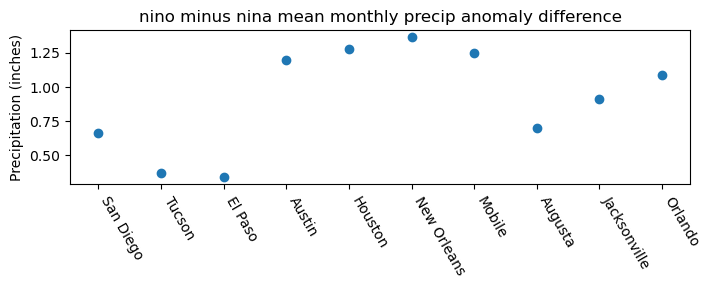

In [37]:
# add your code here
fig = plt.figure(figsize=(8,2))
plt.plot(city_names,diff,marker='o',lw=0)
plt.xticks(rotation=300,ha='left')
plt.ylabel('Precipitation (inches)')
plt.title('nino minus nina mean monthly precip anomaly difference')
plt.show()

<div class="alert alert-info"> 

Now, sort the ```diff``` values in ascending order and save the result to a new variable called ```sorted_diff```. Then, sort the city names according to the order of the values in ```sorted_diff``` and save the result as ```sorted_cities```. 

**Hint:** Take a look at the ```np.argsort()``` example in the NumPy lesson. This is a 3-step process. Using ```np.argsort()``` and saving the result, then using advanced indexing to sort the data values, then using advanced indexing to sort the array of city names.
</div>

In [46]:
# add your code here to sort
sort_order = np.argsort(diff)
sorted_diff = diff[sort_order]
sorted_cities = city_names[sort_order]

print(sorted_diff)
print(sorted_cities)

[0.343049   0.37529476 0.66158146 0.70197226 0.91449788 1.08754188
 1.19782142 1.24560331 1.27626912 1.36386353]
['El Paso' 'Tucson' 'San Diego' 'Augusta' 'Jacksonville' 'Orlando'
 'Austin' 'Mobile' 'Houston' 'New Orleans']


<div class="alert alert-info"> 

Recreate the plot above, but make it a bar chart using matplotlib.pyplot's [```plt.bar()```](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html), plotting the sorted data and city names in ascending order from left to right. 

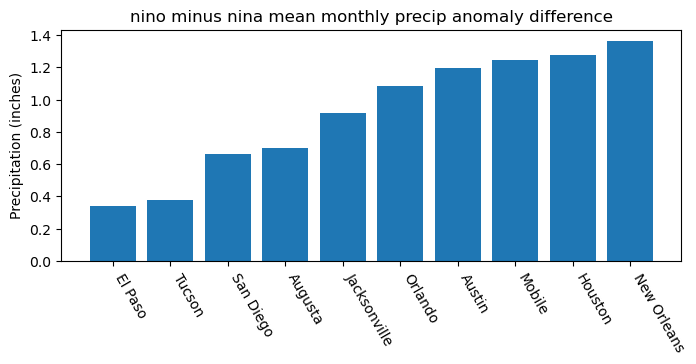

In [47]:
# add your code here to plot
fig = plt.figure(figsize=(8,3))
plt.bar(sorted_cities,sorted_diff)
plt.xticks(rotation=300,ha='left')
plt.ylabel('Precipitation (inches)')
plt.title('nino minus nina mean monthly precip anomaly difference')
plt.show()